# Plots of spectra

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import math
import string
import matplotlib.transforms
import matplotlib.image as image

# Load spectra measured with Shimadzu 3600i spectrophotometer (+SIS) and in-house SIS

In [2]:
BASE_PATH = '/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/'

# Shimadzu SIS data
PATH_SHIMADZU = BASE_PATH + 'Data/Shimadzu/processed_Shimadzu_spectra.csv'
shimadzu = np.genfromtxt(PATH_SHIMADZU, delimiter=',', names=True, dtype=None)
print('Shimadzu column names: ', shimadzu.dtype.names)

# in-house SIS data
PATH_inhouse_SIS = BASE_PATH + 'Data/in-house-SIS/processed_in-house_spectra.csv'
inhouseSIS = np.genfromtxt(PATH_inhouse_SIS, delimiter=',', names=True, dtype=None)
print('\n')
print('in-house SIS column names: ', inhouseSIS.dtype.names)

# Ran's H2O
PATH_Tao_H2O = BASE_PATH + 'Data/in-house-SIS/H2O_Tao/H2O_Tao_mua_only.csv'
Tao_H2O = np.genfromtxt(PATH_Tao_H2O, delimiter=',', names=True, dtype=None)
print('\n')
print('H2O by Tao in in-house SIS column names: ', Tao_H2O.dtype.names)

Shimadzu column names:  ('nm', 'H2O_mua', 'H2O_std', 'DMSO_mua', 'DMSO_std', 'D2O_mua', 'D2O_std', 'melanin_mua', 'melanin_std', 'corn_oil_mua', 'corn_oil_std', 'HbO2_mua', 'HbO2_std', 'Hb_mua', 'Hb_std', 'melanin_DMSO_mua', 'melanin_DMSO_std')


in-house SIS column names:  ('nm', 'lard_mua', 'lard_mua_std', 'lard_mus', 'lard_mus_std', 'lard_mus_fit', 'lard_musp', 'lard_musp_std', 'lard_g', 'WB_S_oxy_mua', 'WB_S_oxy_mua_std', 'WB_S_deoxy_mua', 'WB_S_deoxy_mua_std', 'WB_oxy_mua', 'WB_oxy_mua_std', 'WB_oxy_mus', 'WB_oxy_mus_std', 'WB_oxy_mus_fit', 'WB_oxy_musp', 'WB_oxy_musp_std', 'WB_oxy_g', 'WB_deoxy_mua', 'WB_deoxy_mua_std', 'WB_deoxy_mus', 'WB_deoxy_mus_std', 'WB_deoxy_mus_fit', 'WB_deoxy_musp', 'WB_deoxy_musp_std', 'WB_deoxy_g', 'copolymer_mua', 'copolymer_mua_std', 'copolymer_mus', 'copolymer_mus_std', 'copolymer_mus_fit', 'copolymer_musp', 'copolymer_musp_std', 'copolymer_g', 'agar_mua', 'agar_mua_std', 'agar_mus', 'agar_mus_std', 'agar_mus_fit', 'agar_musp', 'agar_musp_std', 'aga

# Load spectra from literature

In [3]:
# load spectra from literature

# Prahl HbO2 and Hb ref
PATH_Hb = BASE_PATH + 'Data/Reference_Spectra/Hb_HbO2_spectra.txt'
Hb_file = pd.read_csv(PATH_Hb, delimiter='\t', header=[0, 1]) # note: extinction spectra
Hb_abs_const =  2.303 * 150 /64500 # 150 g Hb/litre, 64500 g Hb/mole (typical values from Prahl ref)
HbO2_mua_ref = np.squeeze(Hb_file['Hb02']) * Hb_abs_const
HbO2_wavelengths_ref = np.squeeze(Hb_file['lambda'])
Hb_mua_ref = np.squeeze(Hb_file['Hb']) * Hb_abs_const
Hb_wavelengths_ref = np.squeeze(Hb_file['lambda'])

# Seglestein water
PATH_water = BASE_PATH + 'Data/Reference_Spectra/water_spectrum.txt'
water_data = pd.read_csv(PATH_water, delimiter='\t', header=[0, 1]) # in cm-1
water_wavelengths_ref = np.squeeze(water_data['lambda'])
water_mua_ref = np.squeeze(water_data['absorption'])

# D2O, wavelength in um, k (extinction coefficient)
PATH_D2O = BASE_PATH + 'Data/Reference_Spectra/D2O_k_Kedenburg2012.txt'
D2O_data = pd.read_csv(PATH_D2O, sep=',')
D2O_nm_ref = D2O_data['wl']*1e3 # convert um to nm
D2O_mua_ref = D2O_data['k']*4*np.pi/D2O_nm_ref*1e7 # convert k (entinction coefficient) to mua

# Blood musp
PATH_blood_musp = BASE_PATH + 'Data/Reference_Spectra/blood_musp.txt'
blood_musp_ref = pd.read_csv(PATH_blood_musp, sep='\t')

# SWIR whole blood mua and mus and g, Bosschaart 2013
PATH_SWIRblood = BASE_PATH + 'Data/Reference_Spectra/whole_blood_SWIR_literature.csv'
whole_blood_ref = pd.read_csv(PATH_SWIRblood, sep=",", header=[0])
whole_blood_ref['nm'] = whole_blood_ref['nm'].str.replace(',', '').astype(float) # wavelengths over 1000nm have commas (e.g. 1,005nm) so convert to float
whole_blood_ref = whole_blood_ref[whole_blood_ref['nm'] < 1650.0]
whole_blood_ref = whole_blood_ref[whole_blood_ref['nm'] > 450.0]

# # Pig fat (VIS - NIR data)
PATH_pigfat = BASE_PATH + 'Data/Reference_Spectra/fat_spectrum.txt'
pigfat_file = pd.read_csv(PATH_pigfat, delimiter='\t', header=[0]) # in m-1
pigfat_ref_wavelengths = pigfat_file['nm']
pigfat_ref_mua = pigfat_file['mu_a']* 0.01 # convert to cm-1
pigfat_ref = pd.DataFrame({'nm': pigfat_ref_wavelengths, 'mua[cm-1]': pigfat_ref_mua})

# Human fat - Anderson 2006
PATH_humanfat = BASE_PATH + 'Data/Reference_Spectra/Anderson2006_fat_muaspectrum.csv'
humanfat_mua_ref = pd.read_csv(PATH_humanfat, sep=',', header=[0])
humanfat_mua_ref = humanfat_mua_ref.sort_values(by='nm')

# Melanin 
PATH_melanin = BASE_PATH + 'Data/Reference_Spectra/melanin_mua_SIMPA_ext.txt' # melanosome approximation
melanin_mua_ref = pd.read_csv(PATH_melanin, sep='\t')
PATH_Jacques_1991 = BASE_PATH + 'Data/Reference_Spectra/Jacques_melanin_1991_data.csv' # individual data points
Jacques_1991_mua = pd.read_csv(PATH_Jacques_1991, sep=',')

# Fat mus
PATH_fat_musp = BASE_PATH + 'Data/Reference_Spectra/fat_musp.txt'
fat_musp_ref = pd.read_csv(PATH_fat_musp, sep='\t')

In [4]:
# Make df for blood-H2O titrations

df_Hb = pd.DataFrame({'nm': Hb_wavelengths_ref, 'Hb mua': Hb_mua_ref, 'HbO2 mua': HbO2_mua_ref})
df_water = pd.DataFrame({'nm': water_wavelengths_ref, 'H2O mua': water_mua_ref})
df_Hb_H2O = pd.merge(df_water, df_Hb, on="nm", how="inner")
# water x Hb
df_Hb_H2O["H2OxHb"] = 0.99*df_Hb_H2O["H2O mua"] + 0.01*df_Hb_H2O["Hb mua"]
df_Hb_H2O["H2OxHbO2"] = 0.99*df_Hb_H2O["H2O mua"] + 0.01*df_Hb_H2O["HbO2 mua"]
# Set 'nm' as the index
df_Hb_H2O.set_index('nm', inplace=True)
# sort index so wavelengths are in the right order post merging
df_Hb_H2O = df_Hb_H2O.sort_index()
#-----------------------------------------------------------------------------------------------------------

df_D2O  = pd.DataFrame({'nm': shimadzu['nm'], 'D2O mua': shimadzu['D2O_mua']})
df_HDO = pd.merge(df_water, df_D2O, on="nm", how="inner")
df_HDO["HDO"] = 0.1*df_HDO["H2O mua"] + 0.9*df_HDO["D2O mua"]

# Set 'nm' as the index
df_HDO.set_index('nm', inplace=True)
# sort index so wavelengths are in the right order post merging
df_HDO= df_HDO.sort_index()

In [5]:
# create array with common wavelength axis to compare measured and literature datasets 
#(remove wavelength data that is not common to both / fit to 2nm interval I measured with)
def mix(x_min, x_max, interval, x_1, y_1, x_2, y_2, pc_1):

    # wavelength range
    x_new = np.arange(x_min, x_max+interval, interval)

    # H2O
    y_1 = np.interp(x_new, x_1, y_1)
    # D2O
    y_2 = np.interp(x_new, x_2, y_2)
    # HDO
    y_mix = pc_1*y_1 + (1-pc_1)*y_2
    
    return x_new, y_mix


# Plot

In [6]:
# plots mua and ± standard deviation from df_merged (Shimadzu spectrophotometer data)
def plot_mua(df, mua_column_name, std_column_name, colour, label):

    plt.figure(figsize=(6,3))
    plt.plot(df['nm'], df[mua_column_name], c=colour, lw=2, ls='-', label=label)
    plt.fill_between(df['nm'], df[mua_column_name] - df[std_column_name], df[mua_column_name] 
                     + df[std_column_name], color=colour, lw=2, alpha=0.3, edgecolor=None)
    
    plt.grid(True)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha = 0.5)
    plt.yscale("log")

    plt.ylabel('$\mu_a$ (cm$^{-1}$)',  fontsize=14)
    plt.xlabel('Wavelength (nm)',  fontsize=14)
    plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True, bottom=True)
    plt.minorticks_on()

    return

# Figure 1

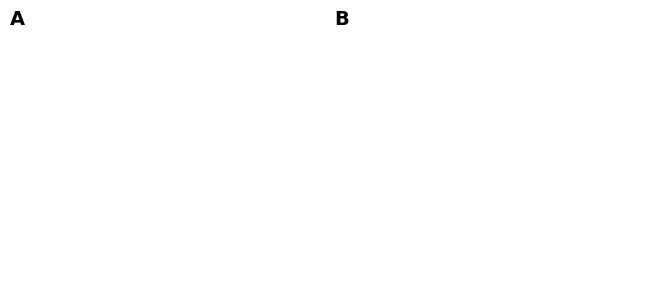

In [7]:
# H2O and D2O
fig, ax = plt.subplots(1, 2, figsize=(6 + (10/16), 3), gridspec_kw={'width_ratios': [1, 1]})
plt.rc('font', size=10) 
# ------------------------------------------------------------------------------------------------------------------------------------------------
# A
ax[0].axis("off")

# ------------------------------------------------------------------------------------------------------------------------------------------------
# B
ax[1].axis("off")


# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

ax = ax.flat

for n, axis in enumerate(ax):
     
    axis.text(-0.25, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------


plt.tight_layout()


plt.savefig(BASE_PATH + 'Plots/Fig1_template.png', dpi=300, bbox_inches='tight', transparent=True)

# Figure 2: H2O and D2O

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


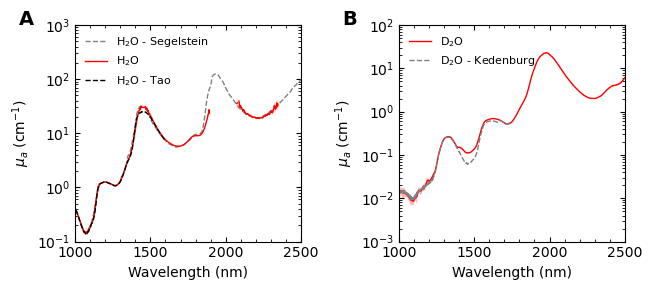

In [8]:
# H2O and D2O
fig, ax = plt.subplots(1, 2, figsize=(6 + (10/16), 3), gridspec_kw={'width_ratios': [1, 1]})
plt.rc('font', size=10) 

# ------------------------------------------------------------------------------------------------------------------------------------------------
# H2O
ax[0].set_yscale("log")
ax[0].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[0].set_xlabel('Wavelength (nm)')
ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[0].minorticks_on()
ax[0].legend(loc=0, fontsize=9)

# literature
ax[0].plot(water_wavelengths_ref, water_mua_ref, c='grey', ls='--', lw=1, label='H$_2$O - Segelstein')
# shimadzu water
ax[0].plot(shimadzu['nm'], shimadzu['H2O_mua'], c='r', lw=1, ls='-', label='H$_2$O')
ax[0].fill_between(shimadzu['nm'], shimadzu['H2O_mua'] - shimadzu['H2O_std'], shimadzu['H2O_mua'] + shimadzu['H2O_std'], color='r', lw=2, alpha=0.3, edgecolor=None)

# H2O by Tao
ax[0].plot(Tao_H2O['nm'], Tao_H2O['muacm1'], c='k', lw=1, ls='--', label='H$_2$O - Tao')
ax[0].fill_between(Tao_H2O['nm'], Tao_H2O['muacm1'] - Tao_H2O['mua_stdcm1'], Tao_H2O['muacm1'] + Tao_H2O['mua_stdcm1'], color='k', lw=2, alpha=0.3, edgecolor=None)


ax[0].set_ylim(0.1, 1000)
ax[0].set_xlim(1000, 2500)
ax[0].legend(loc=2, fontsize=8, frameon=False)

# ------------------------------------------------------------------------------------------------------------------------------------------------
# D2O

ax[1].set_yscale("log")
ax[1].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[1].set_xlabel('Wavelength (nm)')
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[1].minorticks_on()

# shimadzu D2O
ax[1].plot(shimadzu['nm'], shimadzu['D2O_mua'], c='r', lw=1, ls='-', label='D$_2$O')
ax[1].fill_between(shimadzu['nm'], shimadzu['D2O_mua'] - shimadzu['D2O_std'], shimadzu['D2O_mua'] + shimadzu['D2O_std'], color='r', lw=2, alpha=0.3, edgecolor=None)
# literature
ax[1].plot(D2O_nm_ref, D2O_mua_ref, c='grey', ls='--', lw=1, label='D$_2$O - Kedenburg')

ax[1].annotate(r"A", xy=(0.1, 0.1), fontsize=12)


ax[1].legend(loc=2, fontsize=8, frameon=False)
ax[1].set_ylim(0.001, 100)
ax[1].set_xlim(1000, 2500)

# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

ax = ax.flat

for n, axis in enumerate(ax):
     
    axis.text(-0.25, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------


plt.tight_layout()


plt.savefig(BASE_PATH + 'Plots/Fig2.png', dpi=300, bbox_inches='tight', transparent=True)

# Figure 2: whole blood

In [9]:
import miepython as mie

#--------------------------------------------------------------------------------------
# Ran Tao's code

def calculate_Mie_scattering(wavelength_vac_nm: float,
                             n_background: float,
                             n_sphere: float, 
                             dia_sphere_um: float,
                             concentration_sphere_ml: float):
    """
    calculate mu_sp, g using Mie theory
    :param wavelength_vac_nm: wavelength in vacuum [nm]
    :param n_background: refractive index of the background medium
    :param n_sphere: refractive index of the sphere
    :param dia_sphere_um: diameter of the sphere [um]
    :param concentration_sphere_ml: concentration of sphere [spheres/ml]
    :return: mu_sp [mm-1], g
    """
    # calculate relative size parameter: x
    wavelength_vac = wavelength_vac_nm * 1e-3 # convert into [um]
    x = 2 * np.pi * n_background * (dia_sphere_um / 2) / wavelength_vac 
    # calculate relative index: m
    m = n_sphere / n_background

    # Mie scattering
    qext, qsca, qback, g = mie.efficiencies_mx(m, x)

    # calculate mu_s
    sigma_g = np.pi * ((dia_sphere_um / 2) ** 2)  # [um^2]
    sigma_s = qsca * sigma_g  # [um^2]
    mu_s = sigma_s * concentration_sphere_ml * 1e-9  # [1/mm]

    # calculate mu_sp
    mu_sp = mu_s * (1 - g)  # [1/mm]

    return mu_sp, g
#--------------------------------------------------------------------------------------

def mie_spectrum(lambda_range, n_background, n_sphere, dia_sphere_um, concentration_sphere_ml):

    musp_list = []
    g_list = []
    
    for i in range(len(lambda_range)):
        mu_sp, g = calculate_Mie_scattering(lambda_range[i], n_background, n_sphere, dia_sphere_um, concentration_sphere_ml)
        musp_list.append(mu_sp)
        g_list.append(g)

    musp_list = np.array(musp_list) # make numpy array
    g_list = np.array(g_list) # make numpy array

    return musp_list, g_list

# function 'c' to calulate concentration_sphere_ml, hct = haematocrit
def c(d_sphere, hct):
    
    V = 1 # 1 mL volume
    # volume of sphere
    V_sphere = (4/3)*np.pi*((d_sphere*10**(-4))/2)**3 # convert d_sphere from micron to centimitre
    N = (hct * V) / V_sphere #
    
    return N

wavelengths = np.arange(400, 1605, 5)

n_background = 1.33          # water
#n_sphere = 1.4              # assume blood n = 1.35 (n=1.33 for water and assume haemoglobin n=1.4 to average around 1.4)

hct = 0.45 # haematocrit

# 1.35 (n_blood) = n_background*(1-hct) + n_sphere*hct
# =>
n_sphere  = (1.35 - n_background*(1-hct)) / hct

print(n_sphere)

dia_sphere_um_horse = 6.34   # diameter (um)
dia_sphere_um_human = 7.80   # diameter (um)

concentration_sphere_ml_human = c(dia_sphere_um_human, hct)

mie_horse_musp, mie_horse_g = mie_spectrum(wavelengths, n_background, n_sphere, dia_sphere_um_horse, concentration_sphere_ml_human)
mie_human_musp, mie_human_g = mie_spectrum(wavelengths, n_background, n_sphere, dia_sphere_um_human, concentration_sphere_ml_human)



#plt.legend(loc=0, frameon=False)

1.3744444444444444


In [10]:
# plot horse RBC diamter histogram

# path to csv files
PATH_all = BASE_PATH + 'Data/RBCs/All_Populations.csv'
PATH_holey = '/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Horse blood analysis CI Feb26/Holey_Population.csv'

# read csv files with pandas
all = pd.read_csv(PATH_all, delimiter=',', header=[0])
holey = pd.read_csv(PATH_holey, delimiter=',', header=[0])

# calculate median and standard deviation diameter [um]
print('Median diameter of all cells = ', np.median(all['Diameter']))
print('\n')
print('Median diameter of holey cells = ', np.median(holey['Diameter']))
print('\n')
print('Standard deviation of diameter of all cells = ', np.std(all['Diameter']))
print('\n')
print('Standard deviation of diameter of holey cells = ', np.std(holey['Diameter']))
print('\n')

n_bins_all = int((max(all['Diameter']) - min(all['Diameter']))/ 0.05)
print(n_bins_all)
n_bins_holey = int((max(holey['Diameter']) - min(holey['Diameter']))/ 0.05)
print(n_bins_holey)


Median diameter of all cells =  6.340201885


Median diameter of holey cells =  6.771991776


Standard deviation of diameter of all cells =  0.6482952055569884


Standard deviation of diameter of holey cells =  0.461333935423387


148
51


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/91/k1g4cb3560j32d7kkw25c1s00000gn/T/ipykernel_7904/13004935.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


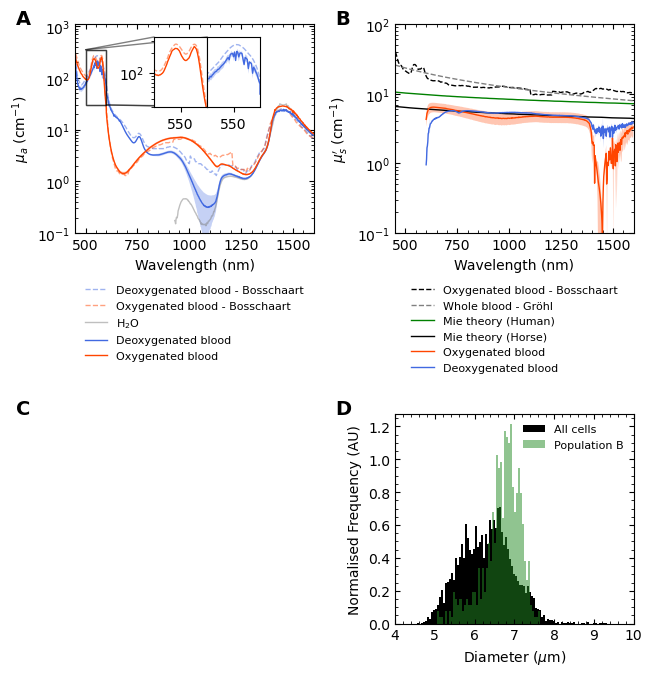

In [11]:

# whole blood oxy scattering
fig, ax = plt.subplots(2, 2, figsize=(6 + (10/16), 7), gridspec_kw={'width_ratios': [1, 1]})
ax = ax.flatten()
plt.rc('font', size=10) 

# ------------------------------------------------------------------------------------------------------------------------------------------------
# Absorption
ax[0].set_yscale("log")
ax[0].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[0].set_xlabel('Wavelength (nm)')
ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[0].minorticks_on()
ax[0].legend(loc=0, fontsize=9)

# literature
ax[0].plot(whole_blood_ref['nm'], whole_blood_ref['mua_deoxy[mm-1]']*10, c='royalblue', alpha=0.5, ls='--', lw=1, label='Deoxygenated blood - Bosschaart')
ax[0].plot(whole_blood_ref['nm'], whole_blood_ref['mua_oxy[mm-1]']*10, c='orangered', alpha=0.5, ls='--', lw=1, label='Oxygenated blood - Bosschaart')

# shimadzu H2O
ax[0].plot(shimadzu['nm'], shimadzu['H2O_mua'], c='grey', alpha=0.5, lw=1, ls='-', label='H$_2$O')

# deoxy
ax[0].plot(inhouseSIS['nm'], inhouseSIS['WB_S_deoxy_mua'], c='royalblue', lw=1, ls='-', label='Deoxygenated blood')
ax[0].fill_between(inhouseSIS['nm'], inhouseSIS['WB_S_deoxy_mua'] - inhouseSIS['WB_S_deoxy_mua_std'], inhouseSIS['WB_S_deoxy_mua'] + inhouseSIS['WB_S_deoxy_mua_std'], color='royalblue', lw=2, alpha=0.3, edgecolor=None)

# oxy
ax[0].plot(inhouseSIS['nm'], inhouseSIS['WB_S_oxy_mua'], c='orangered', lw=1, ls='-', label='Oxygenated blood')
ax[0].fill_between(inhouseSIS['nm'], inhouseSIS['WB_S_oxy_mua'] - inhouseSIS['WB_S_oxy_mua_std'], inhouseSIS['WB_S_oxy_mua'] + inhouseSIS['WB_S_oxy_mua_std'], color='orangered', lw=2, alpha=0.3, edgecolor=None)

# insets
ins_ax_oxy = fig.add_axes([0.24, 0.82, 0.08, 0.1], xlim=[500, 600], ylim=[30, 350], xticks=[550])
ins_ax_oxy.set_yscale('log')
ins_ax_oxy.plot(whole_blood_ref['nm'], whole_blood_ref['mua_oxy[mm-1]']*10, c='orangered', alpha=0.5, ls='--', lw=1)
ins_ax_oxy.plot(inhouseSIS['nm'], inhouseSIS['WB_S_oxy_mua'], c='orangered', lw=1, ls='-', label='Oxygenated blood')
ins_ax_oxy.fill_between(inhouseSIS['nm'], inhouseSIS['WB_S_oxy_mua'] - inhouseSIS['WB_S_oxy_mua_std'], inhouseSIS['WB_S_oxy_mua'] + inhouseSIS['WB_S_oxy_mua_std'], color='orangered', lw=2, alpha=0.3, edgecolor=None)

ins_ax_deoxy = fig.add_axes([0.32, 0.82, 0.08, 0.1], xlim=[500,600], ylim=[30, 350], xticks=[550])
ins_ax_deoxy.set_yscale('log')
ins_ax_deoxy.yaxis.set_visible(False)
ins_ax_deoxy.plot(whole_blood_ref['nm'], whole_blood_ref['mua_deoxy[mm-1]']*10, c='royalblue', alpha=0.5, ls='--', lw=1)
ins_ax_deoxy.plot(inhouseSIS['nm'], inhouseSIS['WB_S_deoxy_mua'], c='royalblue', lw=1, ls='-', label='Deoxygenated blood')
ins_ax_deoxy.fill_between(inhouseSIS['nm'], inhouseSIS['WB_S_deoxy_mua'] - inhouseSIS['WB_S_deoxy_mua_std'], inhouseSIS['WB_S_deoxy_mua'] + inhouseSIS['WB_S_deoxy_mua_std'], color='royalblue', lw=2, alpha=0.3, edgecolor=None)

ax[0].indicate_inset_zoom(ins_ax_oxy, edgecolor='k')
ax[0].indicate_inset_zoom(ins_ax_deoxy, edgecolor='k')

ax[0].set_ylim(0.1, 1100)
ax[0].set_xlim(450, 1600)
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=8, frameon=False)

# ------------------------------------------------------------------------------------------------------------------------------------------------
# Scattering

ax[1].set_yscale("log")
ax[1].set_ylabel('$\mu_s^{\prime}$ (cm$^{-1}$)')
ax[1].set_xlabel('Wavelength (nm)')
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[1].minorticks_on()

# literature
ax[1].plot(whole_blood_ref['nm'], whole_blood_ref['mus_oxy[mm-1]']*10*(1-whole_blood_ref['g']), c='k', ls='--', lw=1, label='Oxygenated blood - Bosschaart')
ax[1].plot(blood_musp_ref["nm"], blood_musp_ref["musp[cm-1]"], lw=1, ls='--', label="Whole blood - Gröhl", color="grey")

# Mie theory
ax[1].plot(wavelengths, mie_human_musp*10, c='g', ls='-', lw=1, label='Mie theory (Human)')  # x 10 to convert to inverse cm
ax[1].plot(wavelengths, mie_horse_musp*10, c='k', ls='-', lw=1, label='Mie theory (Horse)') # x 10 to convert to inverse cm

# oxy
ax[1].plot(inhouseSIS['nm'], inhouseSIS['WB_oxy_musp'], c='orangered', lw=1, ls='-', label='Oxygenated blood')
ax[1].fill_between(inhouseSIS['nm'], inhouseSIS['WB_oxy_musp'] - inhouseSIS['WB_oxy_musp_std'], inhouseSIS['WB_oxy_musp'] + inhouseSIS['WB_oxy_musp_std'], color='orangered', lw=2, alpha=0.3, edgecolor=None)

# deoxy
ax[1].plot(inhouseSIS['nm'], inhouseSIS['WB_deoxy_musp'], c='royalblue', lw=1, ls='-', label='Deoxygenated blood')
ax[1].fill_between(inhouseSIS['nm'], inhouseSIS['WB_deoxy_musp'] - inhouseSIS['WB_deoxy_musp_std'], inhouseSIS['WB_deoxy_musp'] + inhouseSIS['WB_deoxy_musp_std'], color='royalblue', lw=2, alpha=0.3, edgecolor=None)

ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=8, frameon=False)
ax[1].set_ylim(0.1, 100)
ax[1].set_xlim(450, 1600)
# ------------------------------------------------------------------------------------------------------------------------------------------------
# Histogram
ax[3].set_ylabel('Normalised Frequency (AU)')
ax[3].set_xlabel('Diameter ($\mu$m)')
ax[3].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[3].minorticks_on()

ax[3].set_xlim(4,12)
ax[3].set_xticks(ticks=np.arange(4, 12.2, 0.2), minor=True)
ax[3].set_xticks(ticks=np.arange(4, 12.5, 1))

ax[3].hist(all['Diameter'], bins=n_bins_all, density=True, color='k', label='All cells')
ax[3].hist(holey['Diameter'], bins=n_bins_holey, density=True, color='forestgreen', alpha=0.5, label='Population B')

#ax[3].annotate(r"Cell population", xy=(8.5, 1.15), fontsize=8)
ax[3].set_xlim(4,10)
ax[3].legend(loc=0, fontsize=8, frameon=False)
#ax[3].legend(loc='upper center', bbox_to_anchor=(0.3, -0.2), fontsize=8, frameon=False)


# ------------------------------------------------------------------------------------------------------------------------------------------------
# Space for images of RBCs
ax[2].axis("off")

# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

ax = ax.flat

for n, axis in enumerate(ax):
     
    axis.text(-0.25, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()


plt.savefig(BASE_PATH + 'Plots/blood.png', dpi=300, bbox_inches='tight', transparent=True)

# Figure 3: Haemoglobin

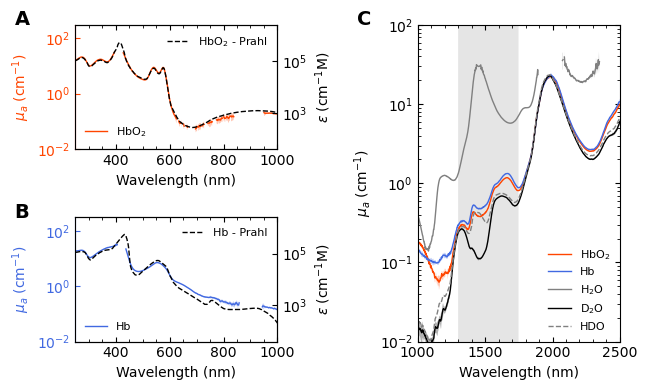

In [12]:
# HDO
HDO_nm, HDO_mua = mix(1000, 2500, 2, df_water['nm'], df_water['H2O mua'], shimadzu['nm'], shimadzu['D2O_mua'], 0.01)

fig = plt.figure(figsize=(6 + (10/16), 4))
plt.rc('font', size=10)

gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0]) 
ax3 = fig.add_subplot(gs[:, 1])

ax1.set_yscale("log")
ax1.set_ylabel('$\mu_a$ (cm$^{-1}$)', )
ax1.set_xlabel('Wavelength (nm)')
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax1.minorticks_on()
ax1.yaxis.label.set_color('orangered')
ax1.tick_params(axis='y', colors='orangered')
ax1.spines['left'].set_color('red')

ax2.set_yscale("log")
ax2.set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax2.set_xlabel('Wavelength (nm)')
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax2.minorticks_on()
ax2.yaxis.label.set_color('royalblue')
ax2.tick_params(axis='y', colors='royalblue')
ax2.spines['left'].set_color('royalblue')

# set up twin axes for Prahl refs
ax12 = ax1.twinx()
ax12.set_ylabel("$\epsilon$ (cm$^{-1}$M)", fontsize=10, color='k')
ax12.tick_params(axis='both', which='both', direction='in', labelsize=10, top=True, right=True)
ax12.set_yscale("log")

ax22 = ax2.twinx()
ax22.set_ylabel("$\epsilon$ (cm$^{-1}$M)", fontsize=10, color='k')
ax22.tick_params(axis='both', which='both', direction='in', labelsize=10, top=True, right=True)
ax22.set_yscale("log")

# Plot data
df = shimadzu
# plot Prahl
ax22.plot(Hb_file['lambda'], Hb_file['Hb'], c='k', lw=1, ls='--', label='Hb - Prahl')
ax12.plot(Hb_file['lambda'], Hb_file['Hb02'], c='k', lw=1, ls='--', label='HbO$_2$ - Prahl')
# HbO2
ax1.plot(df['nm'], df['HbO2_mua'], c='orangered', lw=1, ls='-', label='HbO$_2$')
ax1.fill_between(df['nm'], df['HbO2_mua'] - df['HbO2_std'], df['HbO2_mua'] + df['HbO2_std'], color='orangered', lw=2, alpha=0.3, edgecolor=None)
# Hb
ax2.plot(df['nm'], df['Hb_mua'], c='royalblue', lw=1, ls='-', label='Hb')
ax2.fill_between(df['nm'], df['Hb_mua'] - df['Hb_std'], df['Hb_mua'] + df['Hb_std'], color='royalblue', lw=2, alpha=0.3, edgecolor=None)

# legends
ax1.legend(loc=3, fontsize=8,frameon=False)
ax12.legend(loc=1, fontsize=8,frameon=False)
ax2.legend(loc=3, fontsize=8,frameon=False)
ax22.legend(loc=1, fontsize=8,frameon=False)

# adjust your limits
ax1.set_ylim(0.01, 300)
ax2.set_ylim(0.01, 300)
ax1.set_xlim(250, 1000)
ax2.set_xlim(250, 1000)
ax12.set_ylim(40,2500000)
ax22.set_ylim(40,2500000)

# SWIR data
ax3.set_yscale("log")
ax3.set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax3.set_xlabel('Wavelength (nm)')
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax3.minorticks_on()
ax3.set_xlim(1000,2500)
ax3.set_ylim(0.01,100)

# SWIR plot
start = np.where(shimadzu['nm'] >= 1300)[0][0]
end = np.where(shimadzu['nm'] >= 1750)[0][0]
y = 10000+np.sin(shimadzu['nm'])
ax3.fill_between(shimadzu['nm'][start:end], y[start:end], color='grey', alpha=0.2, edgecolor=None)

# HbO2
ax3.plot(df['nm'], df['HbO2_mua'], c='orangered', lw=1, ls='-', label='HbO$_2$')
ax3.fill_between(df['nm'], df['HbO2_mua'] - df['HbO2_std'], df['HbO2_mua'] + df['HbO2_std'], color='orangered', lw=2, alpha=0.3, edgecolor=None)
# Hb
ax3.plot(df['nm'], df['Hb_mua'], c='royalblue', lw=1, ls='-', label='Hb')
ax3.fill_between(df['nm'], df['Hb_mua'] - df['Hb_std'], df['Hb_mua'] + df['Hb_std'], color='royalblue', lw=2, alpha=0.3, edgecolor=None)
# H2O
ax3.plot(df['nm'], df['H2O_mua'], c='grey', lw=1, ls='-', label='H$_2$O')
ax3.fill_between(df['nm'], df['H2O_mua'] - df['H2O_std'], df['H2O_mua'] + df['H2O_std'], color='gray', lw=2, alpha=0.3, edgecolor=None)
# D2O
ax3.plot(df['nm'], df['D2O_mua'], c='k', lw=1, ls='-', label='D$_2$O')
ax3.fill_between(df['nm'], df['D2O_mua'] - df['D2O_std'], df['D2O_mua'] + df['D2O_std'], color='k', lw=2, alpha=0.3, edgecolor=None)
# HDO
ax3.plot(HDO_nm, HDO_mua, c='gray', lw=1, ls='--', label='HDO')

#ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fontsize=8, frameon=False)
ax3.legend(loc=4, fontsize=8, frameon=False)

# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

for n, axis in enumerate([ax1, ax2, ax3]):
     
    axis.text(-0.3, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------

fig.tight_layout()

plt.savefig(BASE_PATH + 'Plots/Fig4.png', dpi=300, bbox_inches='tight', transparent=True)

# Figure 4: Lipids

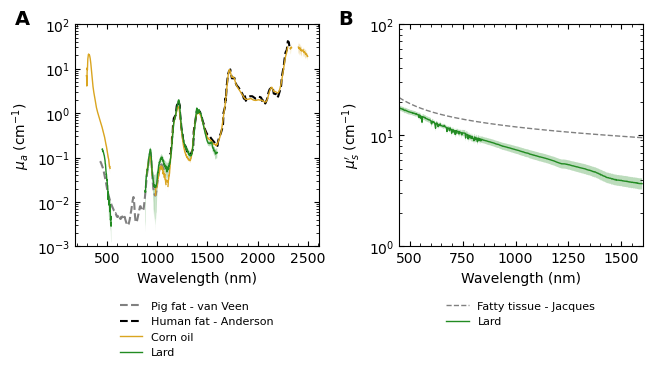

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(6 + (10/16), 4), gridspec_kw={'width_ratios': [1, 1]})
plt.rc('font', size=10) 

# Absorption
ax[0].set_yscale("log")
ax[0].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[0].set_xlabel('Wavelength (nm)')
ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[0].minorticks_on()

# literature
ax[0].plot(pigfat_ref_wavelengths, pigfat_ref_mua, c='grey', lw=1.5, ls='--', label = 'Pig fat - van Veen')
ax[0].plot(humanfat_mua_ref["nm"][::2], humanfat_mua_ref["cm-1"][::2], c='k', marker='', markersize=3, ls='--', lw=1.5, label = 'Human fat - Anderson')

ax[0].plot(shimadzu['nm'], shimadzu['corn_oil_mua'], c='goldenrod', lw=1, ls='-', label='Corn oil')
ax[0].fill_between(shimadzu['nm'], shimadzu['corn_oil_mua'] - shimadzu['corn_oil_std'], shimadzu['corn_oil_mua'] + shimadzu['corn_oil_std'], color='goldenrod', lw=2, alpha=0.3, edgecolor=None)

ax[0].plot(inhouseSIS['nm'], inhouseSIS['lard_mua'], c='forestgreen', lw=1, ls='-', label='Lard')
ax[0].fill_between(inhouseSIS['nm'], inhouseSIS['lard_mua'] - inhouseSIS['lard_mua_std'], inhouseSIS['lard_mua'] + inhouseSIS['lard_mua_std'], color='forestgreen', lw=2, alpha=0.3, edgecolor=None)

ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=8,frameon=False)

# Scattering
ax[1].set_yscale("log")
ax[1].set_ylabel('$\mu_s^{\prime}$ (cm$^{-1}$)')
ax[1].set_xlabel('Wavelength (nm)')
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[1].minorticks_on()

# literature
ax[1].plot(fat_musp_ref["nm"], fat_musp_ref["musp[cm-1]"], lw=1, ls='--', label="Fatty tissue - Jacques", color="grey") 
# Lard
ax[1].plot(inhouseSIS['nm'], inhouseSIS['lard_musp'], c='forestgreen', lw=1, ls='-', label='Lard')
ax[1].fill_between(inhouseSIS['nm'], inhouseSIS['lard_musp'] - inhouseSIS['lard_musp_std'], inhouseSIS['lard_musp'] + inhouseSIS['lard_musp_std'], color='forestgreen', lw=2, alpha=0.3, edgecolor=None)

ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=8,frameon=False)

ax[1].set_xlim(250, 2500)
ax[1].set_xlim(450, 1600)
ax[1].set_ylim(1, 100)
ax[0].set_ylim(0.001, 100)
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

ax = ax.flat

for n, axis in enumerate(ax):
     
    axis.text(-0.25, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()

plt.savefig(BASE_PATH + 'Plots/Fig5.png', dpi=300, bbox_inches='tight', transparent=True)

# Figure 5: Melanin

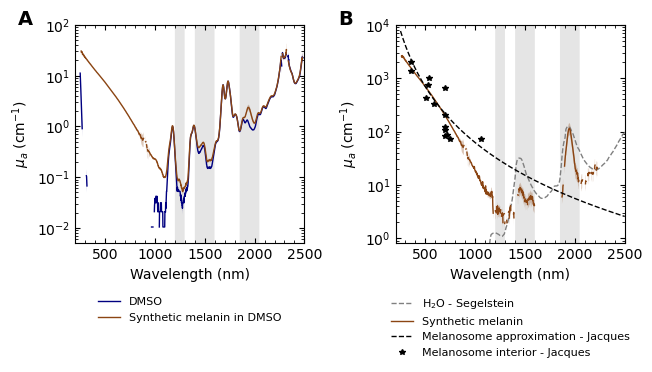

In [14]:
# original

fig, ax = plt.subplots(1, 2, figsize=(6 + (10/16), 4.0), gridspec_kw={'width_ratios': [1, 1]})
plt.rc('font', size=10) 

# Absorption
ax[0].set_yscale("log")
ax[0].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[0].set_xlabel('Wavelength (nm)')
ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[0].minorticks_on()

# in DMSO
ax[0].plot(shimadzu['nm'], shimadzu['DMSO_mua'], c='navy', lw=1, ls='-', label='DMSO') # DMSO only
ax[0].fill_between(shimadzu['nm'], shimadzu['DMSO_mua'] - shimadzu['DMSO_std'], shimadzu['DMSO_mua'] + shimadzu['DMSO_std'], color='navy', lw=2, alpha=0.3, edgecolor=None)
ax[0].plot(shimadzu['nm'], shimadzu['melanin_mua'], c='saddlebrown', lw=1, ls='-', label='Synthetic melanin in DMSO')
ax[0].fill_between(shimadzu['nm'], shimadzu['melanin_mua'] - shimadzu['melanin_std'], shimadzu['melanin_mua'] + shimadzu['melanin_std'], color='saddlebrown', lw=2, alpha=0.3, edgecolor=None)

start = np.where(shimadzu['nm'] >= 1850)[0][0]
end = np.where(shimadzu['nm'] >= 2050)[0][0]
y = 10000+np.sin(shimadzu['nm'])
ax[0].fill_between(shimadzu['nm'][start:end], y[start:end], color='grey', alpha=0.2, edgecolor=None)

start2 = np.where(shimadzu['nm'] >= 1400)[0][0]
end2 = np.where(shimadzu['nm'] >= 1600)[0][0]
ax[0].fill_between(shimadzu['nm'][start2:end2], y[start2:end2], color='grey', alpha=0.2, edgecolor=None)

start3 = np.where(shimadzu['nm'] >= 1200)[0][0]
end3 = np.where(shimadzu['nm'] >= 1300)[0][0]
ax[0].fill_between(shimadzu['nm'][start3:end3], y[start3:end3], color='grey', alpha=0.2, edgecolor=None)

ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=8,frameon=False)

ax[0].set_ylim(0.005, 100)
ax[0].set_xlim(200, 2500)

# subtract DMSO and scale to match Jacques

# Absorption
ax[1].set_yscale("log")
ax[1].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[1].set_xlabel('Wavelength (nm)')
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[1].minorticks_on()

ax[1].fill_between(shimadzu['nm'][start:end], y[start:end], color='grey', alpha=0.2, edgecolor=None)
ax[1].fill_between(shimadzu['nm'][start2:end2], y[start2:end2], color='grey', alpha=0.2, edgecolor=None)
ax[1].fill_between(shimadzu['nm'][start3:end3], y[start3:end3], color='grey', alpha=0.2, edgecolor=None)

# literature for comparison
 #Water
ax[1].plot(water_wavelengths_ref, water_mua_ref, c='grey', ls='--', lw=1, label = 'H$_2$O - Segelstein')

# plot melanin
ax[1].plot(shimadzu['nm'], shimadzu['melanin_DMSO_mua'], c='saddlebrown', lw=1, ls='-', label='Synthetic melanin')
ax[1].fill_between(shimadzu['nm'], shimadzu['melanin_DMSO_mua'] - shimadzu['melanin_DMSO_std'], shimadzu['melanin_DMSO_mua'] + shimadzu['melanin_DMSO_std'], color='saddlebrown', lw=1, ls='-', label=None, alpha=0.3, edgecolor=None)

# Literature references
ax[1].plot(melanin_mua_ref['nm'], melanin_mua_ref['mua[cm-1]'], c='k', lw=1, ls='--', label='Melanosome approximation - Jacques')
ax[1].plot(Jacques_1991_mua['nm'], Jacques_1991_mua['mua[cm-1]'], c='k', marker='*', markersize=4, ls='', label='Melanosome interior - Jacques')

ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=8,frameon=False)
ax[1].set_xlim(200,2500)
ax[1].set_ylim(0.8, 10000)
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

ax = ax.flat

for n, axis in enumerate(ax):
     
    axis.text(-0.25, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()

plt.savefig(BASE_PATH + 'Plots/Fig6.png', dpi=300, bbox_inches='tight', transparent=True)

# Figure 6: summary spectra

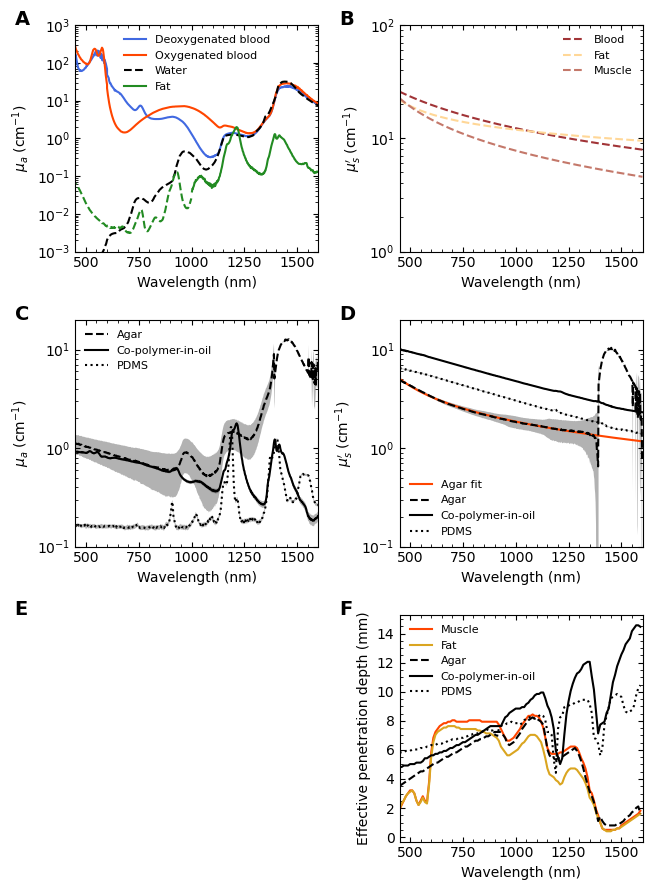

In [15]:
# PATH to simulation spectra
PATH = '/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/Data/Simulation_Spectra/'
#------------------------------------------------------------------------------------------------------------------------------------------------------
# function to remove NaNs from spectra
def dropna(df):
    df_filtered = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df_filtered
#------------------------------------------------------------------------------------------------------------------------------------------------------
## PHANTOMS / MUA & MUSP [cm-1] ##

# PDMS phantom
PDMS = pd.read_csv(PATH+"PDMS_mua_musp.txt", sep='\t')
# co-polymer-in-oil phantom
copolymer= pd.read_csv(PATH+"copolymer_mua_musp.txt", sep='\t')
# agar phantom 
agar = pd.read_csv(PATH+"agar_mua_musp.txt", sep='\t')
#------------------------------------------------------------------------------------------------------------------------------------------------------
## TISSUE COMPONENTS ABSORPTION / MUA [cm-1] ##
    
# fat - van Veen + MJW
fat_mua = pd.read_csv(PATH+"fat_mua.txt", sep='\t') # pig fat (van Veen) 450-1000nm, lard (MJW) 1000-1600nm
fat_mua = dropna(fat_mua)
# oxy blood - MJW
oxy_blood_mua = pd.read_csv(PATH+"oxy_blood_mua.txt", sep='\t')
oxy_blood_mua = dropna(oxy_blood_mua)
# deoxy blood - MJW
deoxy_blood_mua = pd.read_csv(PATH+"deoxy_blood_mua.txt", sep='\t')
deoxy_blood_mua = dropna(deoxy_blood_mua)
# water - Segelstein
water_mua = pd.read_csv(PATH+"water_mua.txt", sep='\t')

#------------------------------------------------------------------------------------------------------------------------------------------------------
## TISSUE COMPONENTS REDUCED SCATTERING / MUSP [cm-1] ##

# fat
fat_musp = pd.read_csv(PATH+"fat_musp.txt", sep='\t')
# blood
blood_musp = pd.read_csv(PATH+"blood_musp.txt", sep='\t')
# muscle
muscle_musp = pd.read_csv(PATH+"muscle_musp.txt", sep='\t')
#------------------------------------------------------------------------------------------------------------------------------------------------------
## LOAD SIMULATION RESULTS 
EPD = pd.read_csv('/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/Data/Simulation_results_2026-05-17/EPD.txt', sep='\t')

# Plot the spectra

fig, ax = plt.subplots(3, 2, figsize=(6 + (10/16), 9), gridspec_kw={'width_ratios': [1, 1]})
ax = ax.flatten()
plt.rc('font', size=10) 

# absorption
ax[0].plot(deoxy_blood_mua["nm"], deoxy_blood_mua["mua[cm-1]"], label="Deoxygenated blood", color="royalblue")
ax[0].plot(oxy_blood_mua["nm"], oxy_blood_mua["mua[cm-1]"], label="Oxygenated blood", color="orangered")
ax[0].plot(water_mua["nm"], water_mua["mua[cm-1]"], label="Water", color="k", ls='--')
filter_fat_vis = fat_mua[fat_mua["nm"] < 1000]
ax[0].plot(filter_fat_vis["nm"], filter_fat_vis["mua[cm-1]"], label=None, color="forestgreen", ls='--')
filter_fat_SWIR = fat_mua[fat_mua["nm"] > 1000]
ax[0].plot(filter_fat_SWIR["nm"], filter_fat_SWIR["mua[cm-1]"], label="Fat", color="forestgreen")

# scattering

# define colours
c_blood = (161/255,52/255,55/255)
c_fat = (255/255,215/255,151/255)
c_muscle = (196/255,120/255,106/255)

ax[1].plot(blood_musp["nm"], blood_musp["musp[cm-1]"], label="Blood", color=c_blood, ls='--')
ax[1].plot(fat_musp["nm"], fat_musp["musp[cm-1]"], label="Fat", color=c_fat, ls='--')
ax[1].plot(muscle_musp["nm"], muscle_musp["musp[cm-1]"], label="Muscle", color=c_muscle, ls='--')

# PHANTOMS

# plot agar
ax[2].plot(inhouseSIS['nm'], inhouseSIS['agar_mua'], c='k', lw=1.5, ls='--', label='Agar')
ax[2].fill_between(inhouseSIS['nm'], inhouseSIS['agar_mua'] - inhouseSIS['agar_mua_std'], inhouseSIS['agar_mua'] + inhouseSIS['agar_mua_std'], color='k', lw=2, alpha=0.3, edgecolor=None)
# plot co-polymer-in-oil
ax[2].plot(inhouseSIS['nm'], inhouseSIS['copolymer_mua'], c='k', lw=1.5, ls='-', label='Co-polymer-in-oil')
ax[2].fill_between(inhouseSIS['nm'], inhouseSIS['copolymer_mua'] - inhouseSIS['copolymer_mua_std'], inhouseSIS['copolymer_mua'] + inhouseSIS['copolymer_mua_std'], color='k', lw=2, alpha=0.3, edgecolor=None)
# plot PDMS
ax[2].plot(inhouseSIS['nm'], inhouseSIS['PDMS_mua'], c='k', lw=1.5, ls=':', label='PDMS')
ax[2].fill_between(inhouseSIS['nm'], inhouseSIS['PDMS_mua'] - inhouseSIS['PDMS_mua_std'], inhouseSIS['PDMS_mua'] + inhouseSIS['PDMS_mua_std'], color='k', lw=2, alpha=0.3, edgecolor=None)

# plot agar
ax[3].plot(inhouseSIS['nm'], inhouseSIS['agar_musp_fit'], c='orangered', lw=1.5, ls='-', label='Agar fit')
ax[3].plot(inhouseSIS['nm'], inhouseSIS['agar_musp'], c='k', lw=1.5, ls='--', label='Agar')
ax[3].fill_between(inhouseSIS['nm'], inhouseSIS['agar_musp'] - inhouseSIS['agar_musp_std'], inhouseSIS['agar_musp'] + inhouseSIS['agar_musp_std'], color='k', lw=2, alpha=0.3, edgecolor=None)

# plot co-polymer-in-oil
ax[3].plot(inhouseSIS['nm'], inhouseSIS['copolymer_musp'], c='k', lw=1.5, ls='-', label='Co-polymer-in-oil')
ax[3].fill_between(inhouseSIS['nm'], inhouseSIS['copolymer_musp'] - inhouseSIS['copolymer_musp_std'], inhouseSIS['copolymer_musp'] + inhouseSIS['copolymer_musp_std'], color='k', lw=2, alpha=0.3, edgecolor=None)
# plot PDMS
ax[3].plot(inhouseSIS['nm'], inhouseSIS['PDMS_musp'], c='k', lw=1.5, ls=':', label='PDMS')
ax[3].fill_between(inhouseSIS['nm'], inhouseSIS['PDMS_musp'] - inhouseSIS['PDMS_musp_std'], inhouseSIS['PDMS_musp'] + inhouseSIS['PDMS_musp_std'], color='k', lw=2, alpha=0.3, edgecolor=None)

ax[5].plot(EPD['nm'], EPD['muscle[mm]'], c='orangered', marker='', ls='-', label='Muscle', lw=1.5)
ax[5].plot(EPD['nm'], EPD['fat[mm]'], c='goldenrod', marker='', ls='-', label='Fat', lw=1.5)
ax[5].plot(EPD['nm'], EPD['Agar[mm]'], c='k', marker='', ls='--', label='Agar', lw=1.5)
ax[5].plot(EPD['nm'], EPD['copolymer[mm]'], c='k', marker='', ls='-', label='Co-polymer-in-oil', lw=1.5)
ax[5].plot(EPD['nm'], EPD['PDMS[mm]'], c='k', marker='', ls=':', label='PDMS', lw=1.5)

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")
ax[3].set_yscale("log")

ax[0].set_xlim(450, 1600)
ax[1].set_xlim(450, 1600)
ax[2].set_xlim(450, 1600)
ax[3].set_xlim(450, 1600)
ax[5].set_xlim(450, 1600)

ax[0].set_ylim(0.001, 1000)
ax[1].set_ylim(1, 100)
ax[2].set_ylim(0.1, 20)
ax[3].set_ylim(0.1, 20)

ax[0].legend(loc=0, fontsize=8,frameon=False)
ax[1].legend(loc=0, fontsize=8,frameon=False)
ax[2].legend(loc=0, fontsize=8,frameon=False)
ax[3].legend(loc=0, fontsize=8,frameon=False)
ax[5].legend(loc=0, fontsize=8,frameon=False)


ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[0].minorticks_on()
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[1].minorticks_on()

ax[2].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[2].minorticks_on()
ax[3].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[3].minorticks_on()
ax[5].tick_params(axis='both', which='both', direction='in', top=True, right=True, bottom=True)
ax[5].minorticks_on()

ax[0].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[0].set_xlabel('Wavelength (nm)')
ax[1].set_ylabel('$\mu_s^{\prime}$ (cm$^{-1}$)')
ax[1].set_xlabel('Wavelength (nm)')
ax[2].set_ylabel('$\mu_a$ (cm$^{-1}$)')
ax[2].set_xlabel('Wavelength (nm)')
ax[3].set_ylabel('$\mu_s^{\prime}$ (cm$^{-1}$)')
ax[3].set_xlabel('Wavelength (nm)')

ax[4].axis("off")

ax[5].set_ylabel('Effective penetration depth (mm)')
ax[5].set_xlabel('Wavelength (nm)')
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ADD PANEL LABELS

for n, axis in enumerate(ax):
     
    axis.text(-0.25, 1.0, string.ascii_uppercase[n], transform=axis.transAxes, size=14, weight='bold')
# ------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()

plt.savefig(BASE_PATH + 'Plots/simulations.png', dpi=300, bbox_inches='tight', transparent=True)